# Глубинное обучение 1 / Введение в глубинное обучение, ФКН ВШЭ

## Домашнее задание 2: сверточный классификатор.

### Общая информация

Оценка после штрафа после мягкого дедлайна вычисляется по формуле $M_{\text{penalty}} = M_{\text{full}} \cdot 0.85^{t/1440}$, где $M_{\text{full}}$ — полная оценка за работу без учета штрафа, а $t$ — время в минутах, прошедшее после мягкого дедлайна (округление до двух цифр после запятой). Таким образом, спустя первые сутки после мягкого дедлайна вы не можете получить оценку выше 8.5, а если сдать через четыре дня после мягкого дедлайна, то ваш максимум — 5.22 балла.

### Оценивание и штрафы

Максимально допустимая оценка за работу — 10 баллов. Сдавать задание после указанного срока сдачи нельзя.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

### О задании

В этом задании вам предстоит познакомиться со сверточными сетями и их обучением для классификации изображений с использованием библиотеки PyTorch.


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split

## 0. Загрузка данных

Работать мы будем с набором данных [CIFAR10](https://www.cs.toronto.edu/~kriz/cifar.html). CIFAR10 представляет собой набор изображений 32х32 пикселя, разделенных на 10 классов.

![title](https://pytorch.org/tutorials/_images/cifar10.png)




Набор данных уже определен в <code>torchvision.datasets</code>, так что возьмем его оттуда.



In [3]:
def get_cifar10_data(batch_size, transform_train):
    torch.manual_seed(0)
    np.random.seed(0)

    transform_test = transforms.Compose(
        [transforms.ToTensor(),
         # Переводим цвета пикселей в отрезок [-1, 1]
         transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
    )

    # Загружаем данные
    trainvalset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                               download=True, transform=transform_train)
    testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                           download=True, transform=transform_test)

    # В датасете определено разбиение только на train и test,
    # так что валидацию дополнительно выделяем из обучающей выборки
    train_idx, valid_idx = train_test_split(np.arange(len(trainvalset)), test_size=0.3,
                                            shuffle=True, random_state=0)
    trainset = torch.utils.data.Subset(trainvalset, train_idx)
    valset = torch.utils.data.Subset(trainvalset, valid_idx)

    train_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                               shuffle=True, num_workers=2)
    val_loader = torch.utils.data.DataLoader(valset, batch_size=batch_size,
                                             shuffle=False, num_workers=2)
    test_loader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                              shuffle=False, num_workers=2)

    return train_loader, val_loader, test_loader


In [4]:
transform = transforms.Compose(
        [transforms.ToTensor(),
         transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
)

train_loader, val_loader, test_loader = get_cifar10_data(batch_size=64,
                                                         transform_train=transform)

100%|██████████| 170M/170M [00:06<00:00, 25.9MB/s]


Посмотрим на изображения:

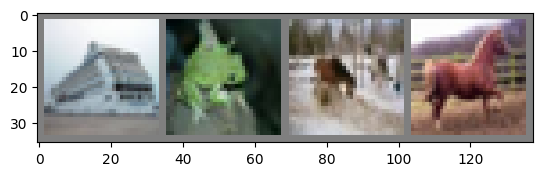

ship frog horse horse


In [5]:
def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


dataiter = iter(train_loader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images[:4]))

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
print(*[classes[labels[i]] for i in range(4)])

## 1. Задание сверточной сети (3 балла)

Теперь нам нужно задать сверточную нейронную сеть, которую мы будем обучать классифицировать изображения.

Используем сеть, основанную на одном блоке архитектуры ResNet.

<img src="https://i.ibb.co/2hg962h/basic-block.png" width="500"/>

__Указания:__

- Все сверточные слои должны иметь 32 выходных канала, а также не должны изменять ширину и высоту изображения.
- Выход блока сократите до размерности 32х4х4, применив average pooling.
- Для получения итоговых логитов, распрямите выход пулинга в вектор из 512 элементов, а затем пропустите его через линейный слой.

**Задание 1.1 (3 балла).**

Определите архитектуру сети соответственно схеме и указаниям выше.

Ключевые слова: <code>Conv2d</code>, <code>BatchNorm2d</code>, <code>AvgPool2d</code>.

In [6]:
n_classes = 10



class BasicBlockNet(nn.Module):
    def __init__(self, in_channels):
        super().__init__()

        self.in_channels = in_channels

        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu= nn.ReLU()
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.conv = nn.Conv2d(in_channels, 32, kernel_size=1, padding=0)
        self.pool = nn.AdaptiveAvgPool2d((4,4))
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(512, n_classes)
    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        out+= self.conv(x)
        out = self.pool(self.relu(out))
        out = self.flatten(out)
        out = self.linear(out)

        return out


In [27]:
net = BasicBlockNet(3)
net

BasicBlockNet(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv): Conv2d(3, 32, kernel_size=(1, 1), stride=(1, 1))
  (pool): AdaptiveAvgPool2d(output_size=(4, 4))
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear): Linear(in_features=512, out_features=10, bias=True)
)

Проверим, что выход сети имеет корректную размерность:

In [28]:
assert net(torch.zeros((10, 3, 32, 32))).shape == (10, 10)

Чтобы проводить вычисления на GPU, в PyTorch необходимо руками перекладывать объекты, с которыми вы хотите проводить вычисления, на графический ускоритель. Это делается следующим образрм:

In [29]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [30]:
net = net.to(device)

Подключение GPU в google.colab:

**Среда выполнения** -> **Сменить среду выполнения** -> **Аппаратный ускоритель** -> **GPU**

## 2. Обучение и тестирование модели (3 балла)

**Задание 2.1 (2 балла).** Переходим к обучению модели. Заполните пропуски в функциях <code>test</code> и <code>train_epoch</code>. В качестве функции потерь будем использовать [кросс-энтропию](https://pytorch.org/docs/stable/generated/torch.nn.functional.cross_entropy.html), а в качестве метрики качества accuracy.

In [43]:
criterion = nn.CrossEntropyLoss()

def test(model, loader):
    loss_log = []
    acc_log = []
    model.eval()

    with torch.no_grad():
        for data, target in loader:
            data = data.to(device)
            target = target.to(device)
            logits = model(data)
            loss = criterion(logits, target)
            loss_log.append(loss.item())

            preds = logits.argmax(dim=1)
            acc = (preds == target).float().mean()
            acc_log.append(acc.item())


    return np.mean(loss_log), np.mean(acc_log)

def train_epoch(model, optimizer, train_loader):
    loss_log = []
    acc_log = []
    model.train()

    for data, target in train_loader:
        data = data.to(device)
        target = target.to(device)
        optimizer.zero_grad()
        logits = model(data)
        loss = criterion(logits, target)
        loss.backward()
        optimizer.step()

        loss_log.append(loss.item())

        preds = logits.argmax(dim=1)
        acc = (preds == target).float().mean()

        acc_log.append(acc.item())

    return loss_log, acc_log

def train(model, optimizer, n_epochs, train_loader, val_loader, scheduler=None):
    train_loss_log, train_acc_log, val_loss_log, val_acc_log = [], [], [], []

    for epoch in range(n_epochs):
        train_loss, train_acc = train_epoch(model, optimizer, train_loader)
        val_loss, val_acc = test(model, val_loader)

        train_loss_log.extend(train_loss)
        train_acc_log.extend(train_acc)

        val_loss_log.append(val_loss)
        val_acc_log.append(val_acc)

        print(f"Epoch {epoch}")
        print(f" train loss: {np.mean(train_loss)}, train acc: {np.mean(train_acc)}")
        print(f" val loss: {val_loss}, val acc: {val_acc}\n")

        if scheduler is not None:
            scheduler.step()

    return train_loss_log, train_acc_log, val_loss_log, val_acc_log

Запустим обучение модели. В качестве оптимизатора будем использовать стохастический градиентный спуск, который является де-факто стандартом в задачах компьютерного зрения (наравне с <code>Adam</code>).

__Замечание:__ Для достижения наилучшего качества в нашем случае потребуется обучать модель несколько сотен эпох. Однако в целях экономии вашего времени и сил, во всех экспериментах мы ограничимся 20 эпохами.

In [32]:
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
train_loss_log, train_acc_log, val_loss_log, val_acc_log = train(net, optimizer, 20, train_loader, val_loader)

Epoch 0
 train loss: 1.4821650004474074, train acc: 0.4721043353978633
 val loss: 1.218071719179762, val acc: 0.5715868795171697

Epoch 1
 train loss: 1.1564342754414574, train acc: 0.593227670441162
 val loss: 1.1224931757500831, val acc: 0.6124778369639782

Epoch 2
 train loss: 1.0514319955321945, train acc: 0.6354710760456552
 val loss: 1.0349030593608288, val acc: 0.6381648936170212

Epoch 3
 train loss: 0.9928662283329031, train acc: 0.6535077696526508
 val loss: 1.0708526644300906, val acc: 0.6314273050490846

Epoch 4
 train loss: 0.9552716184577733, train acc: 0.6669169496574611
 val loss: 0.9768554773736507, val acc: 0.6613918441407224

Epoch 5
 train loss: 0.9200551410697714, train acc: 0.6800853683046275
 val loss: 0.9488595549096452, val acc: 0.6708998228641266

Epoch 6
 train loss: 0.8989782096916841, train acc: 0.6872225124831609
 val loss: 0.9516694099345105, val acc: 0.6771941489361702

Epoch 7
 train loss: 0.8719314289921163, train acc: 0.6991626404539105
 val loss: 0.9

Посчитайте точность на тестовой выборке:

In [33]:
test(net, test_loader)

(np.float64(0.8853784070652762), np.float64(0.699343152866242))

Если вы все сделали правильно, у вас должна была получиться точность $\ge 67\%$.

**Задание 2.2 (1 балл).** Постройте графики зависимости функции потерь и точности классификации от номера шага оптимизатора. На каждом графике расположите данные и для обучающей и для валидационной выборки, итого у вас должно получиться два графика. Обратите внимание, что на обучающей выборке эти данные считаются по каждому батчу, на валидационной же они считаются по всей выборке раз в эпоху.

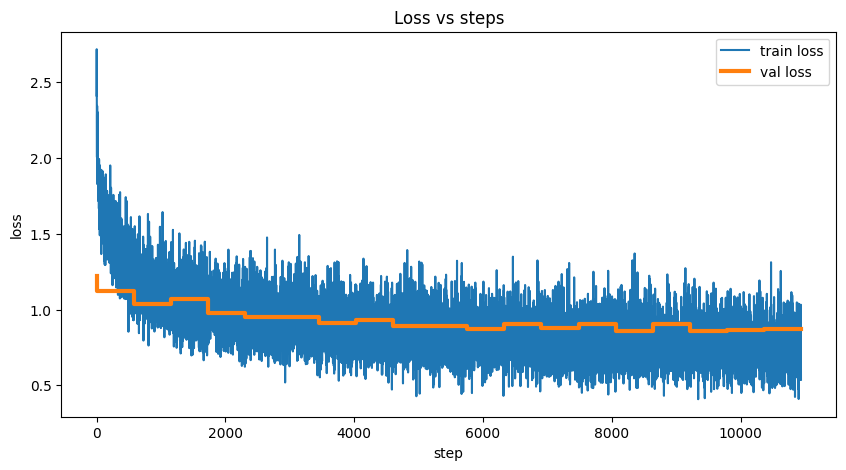

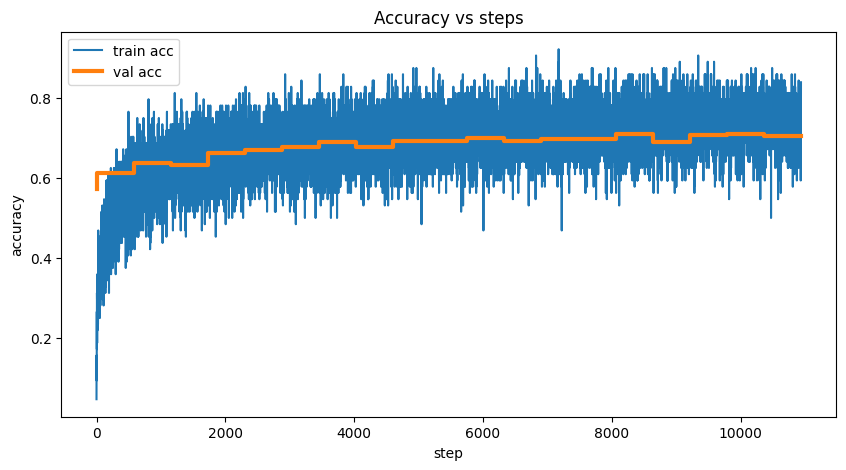

In [34]:
plt.figure(figsize=(10,5))
plt.plot(train_loss_log, label='train loss')
plt.step(np.linspace(0, len(train_loss_log), len(val_loss_log)),
         val_loss_log, label='val loss', linewidth=3)
plt.xlabel('step')
plt.ylabel('loss')
plt.title('Loss vs steps')
plt.legend()
plt.show()



plt.figure(figsize=(10,5))
plt.plot(train_acc_log, label='train acc')
plt.step(np.linspace(0, len(train_acc_log), len(val_acc_log)),
         val_acc_log, label='val acc', linewidth=3)
plt.xlabel('step')
plt.ylabel('accuracy')
plt.title('Accuracy vs steps')
plt.legend()
plt.show()


## 3. Расписание длины шага (2 балла)

С курса "Машинное обучение 1" вы уже должны знать, что сходимость стохастического градиентного спуска мы можем теоретически гарантировать только если будем определенным образом со временем уменьшать длину шага. На практике при обучении нейронных сетей такая техника оказывается очень полезной, однако теоретически обоснованными способами уменьшения длины шага фантазия не ограничивается.

Одним из простейших способов является кусочно постоянная функция: на нескольких фиксированных эпохах уменьшаем длину шага в константу раз.

In [ ]:
net = BasicBlockNet(3).to(device)
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10, 15], gamma=0.1)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(net, optimizer, 20, train_loader, val_loader, scheduler)

Epoch 0
 train loss: 1.4779584739064386, train acc: 0.4739610538622143
 val loss: 1.2525146854684708, val acc: 0.5516179079705096

Epoch 1
 train loss: 1.1515031841598873, train acc: 0.5964595847635427
 val loss: 1.0575505586380654, val acc: 0.6336436170212766

Epoch 2
 train loss: 1.0428741588453052, train acc: 0.6359974862888482
 val loss: 1.0386909680163607, val acc: 0.6310505319148936

Epoch 3
 train loss: 0.9860011399119166, train acc: 0.6584617394198011
 val loss: 0.9973635163713008, val acc: 0.6536347518575952

Epoch 4
 train loss: 0.9533269088272639, train acc: 0.6687532645910705
 val loss: 0.993981557450396, val acc: 0.6594636526513606

Epoch 5
 train loss: 0.9209051053746309, train acc: 0.6826602899396224
 val loss: 0.9897192145915742, val acc: 0.6625

Epoch 6
 train loss: 0.9029905093217463, train acc: 0.6853453904880684
 val loss: 0.9112463106500341, val acc: 0.6895168441407225

Epoch 7
 train loss: 0.8826866737231476, train acc: 0.6936863411279222
 val loss: 0.921938527137

Посчитайте точность на тестовой выборке:

In [ ]:
test(net, test_loader)

(np.float64(0.8277646903019802), np.float64(0.7138734076433121))

**Задание 3.0 (0.5 баллов).** Здесь может возникнуть вопрос: а что будет, если мы не будем уменьшать длину шага в процессе обучения, а сразу возьмем констатную, равную значению нашей кусочно-постоянной функции на последних эпохах, то есть $0.001$ в нашем случае. Запустите обучение и проверьте, что в таком случае мы получим худшее качество на тестовой выборке.

In [ ]:
net = BasicBlockNet(3).to(device)
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)
train_loss_log, train_acc_log, val_loss_log, val_acc_log = train(net, optimizer, 20, train_loader, val_loader)

Epoch 0
 train loss: 1.8184967339583682, train acc: 0.36024826982993313
 val loss: 1.6006628477827032, val acc: 0.4427748227373083

Epoch 1
 train loss: 1.5241192871299478, train acc: 0.4636736093752999
 val loss: 1.442116984915226, val acc: 0.4904476950777338

Epoch 2
 train loss: 1.4066973120464485, train acc: 0.5057741904825354
 val loss: 1.3608348770344512, val acc: 0.5210992908224147

Epoch 3
 train loss: 1.3389368534524, train acc: 0.5281241839067156
 val loss: 1.2936949859274194, val acc: 0.5423537234042554

Epoch 4
 train loss: 1.2833874755193373, train acc: 0.5514698681273452
 val loss: 1.251052959168211, val acc: 0.5556959220703612

Epoch 5
 train loss: 1.2360112236666287, train acc: 0.5648504832327039
 val loss: 1.1982392011804783, val acc: 0.5765514184819891

Epoch 6
 train loss: 1.1888257296691211, train acc: 0.5837563659852776
 val loss: 1.162400127979035, val acc: 0.5966976950777337

Epoch 7
 train loss: 1.1435574310571228, train acc: 0.59878558378115
 val loss: 1.159878

In [ ]:
test(net, test_loader)

(np.float64(0.9585799886162873), np.float64(0.6650079617834395))

И правда получили хуже

**Задание 3.1 (1.5 балла).** Изучите, какие еще способы уменьшения длины шага представлены в <code>torch.optim.lr_scheduler</code>. Выберите несколько из них, объясните, как они устроены, и обучите модель с ними. Удалось ли добиться улучшения качества на тестовой выборке?

Возьмем 3 штуки

##1) ExponentialLR


$lr_{\text{new}} = lr_0 \cdot \gamma^{\text{epoch}}$

Шаг уменьшается плавно каждую эпоху


##2) CosineAnnealingLR

lr убывает по косинусу:

$lr(t) = lr_{\min} +  \frac{1}{2}(lr_{\max} - lr_{\min})\left(1 + \cos\left(\frac{t\pi}{T_{\max}}\right)\right)$

где  
* $t $ — текущая эпоха  
* $T_{\max}$ - период  
* $lr_{\max}, lr_{\min} $ — верхняя и нижняя границы

## 3) CosineAnnealingWarmRestarts

Уменьшает lr по косинусу но переодически опять отбрасывает его вверх (помогает выбраться из локального минимума)

$lr(t) = lr_{\min} + \frac{1}{2}(lr_{\max} - lr_{\min})\left(1 + \cos\left(\frac{t\pi}{T}\right)\right)$

После завершения цикла learning rate снова поднимается:

$lr \leftarrow lr_{\max}$




In [ ]:
#ExponentialLR
net = BasicBlockNet(3).to(device)
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(net, optimizer, 20, train_loader, val_loader, scheduler)
a1, b1 = test(net, test_loader)


Epoch 0
 train loss: 1.500802198537307, train acc: 0.46375522338929953
 val loss: 1.297391463340597, val acc: 0.5433289007937655

Epoch 1
 train loss: 1.1839983437135406, train acc: 0.5840869026166647
 val loss: 1.1172146457306882, val acc: 0.6093528369639782

Epoch 2
 train loss: 1.0642253501541654, train acc: 0.6295132541133455
 val loss: 1.059570543816749, val acc: 0.6354609930768926

Epoch 3
 train loss: 0.9948921025997978, train acc: 0.653107861060329
 val loss: 1.0511492003785803, val acc: 0.6397384752618506

Epoch 4
 train loss: 0.9588327634487117, train acc: 0.6644236420364659
 val loss: 0.9895578488390496, val acc: 0.6540115248649678

Epoch 5
 train loss: 0.9250912143281871, train acc: 0.6775145273539877
 val loss: 0.9715380584939998, val acc: 0.6629210994598713

Epoch 6
 train loss: 0.898663186612905, train acc: 0.6874469509944183
 val loss: 0.9572160822279909, val acc: 0.6667553191489362

Epoch 7
 train loss: 0.8808105417971637, train acc: 0.6930375098092465
 val loss: 0.935

In [ ]:
#CosineAnnealingLR
net = BasicBlockNet(3).to(device)
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=20,eta_min=1e-5)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(net, optimizer, 20, train_loader, val_loader, scheduler)
a2, b2 = test(net, test_loader)



Epoch 0
 train loss: 1.463035590905812, train acc: 0.47469149908592323
 val loss: 1.2749438392355088, val acc: 0.5523936170212767

Epoch 1
 train loss: 1.1668062388787976, train acc: 0.5911832398426816
 val loss: 1.0850615014421179, val acc: 0.616156914893617

Epoch 2
 train loss: 1.0507190597994454, train acc: 0.635046683238237
 val loss: 1.0208802322123913, val acc: 0.6463430851063829

Epoch 3
 train loss: 0.9888480098635448, train acc: 0.6561928702010968
 val loss: 0.9922610275288846, val acc: 0.6593971632896586

Epoch 4
 train loss: 0.9457329099749299, train acc: 0.6733277291876743
 val loss: 0.9642656265421117, val acc: 0.6625886526513607

Epoch 5
 train loss: 0.9092389880739139, train acc: 0.6842313594094578
 val loss: 0.9439282455342881, val acc: 0.6718306739279565

Epoch 6
 train loss: 0.8843437324276354, train acc: 0.6964000065758198
 val loss: 0.9533422893666207, val acc: 0.6637189718002968

Epoch 7
 train loss: 0.8535095629243136, train acc: 0.706010054844607
 val loss: 0.95

In [ ]:
criterion = nn.CrossEntropyLoss()

def test(model, loader):
    loss_log = []
    acc_log = []
    model.eval()

    with torch.no_grad():
        for data, target in loader:
            data = data.to(device)
            target = target.to(device)
            logits = model(data)
            loss = criterion(logits, target)
            loss_log.append(loss.item())

            preds = logits.argmax(dim=1)
            acc = (preds == target).float().mean()
            acc_log.append(acc.item())


    return np.mean(loss_log), np.mean(acc_log)

def train_epoch(model, optimizer, train_loader,scheduler=None ):
    loss_log = []
    acc_log = []
    model.train()

    for data, target in train_loader:
        data = data.to(device)
        target = target.to(device)
        optimizer.zero_grad()
        logits = model(data)
        loss = criterion(logits, target)
        loss.backward()
        optimizer.step()

        if isinstance(scheduler, torch.optim.lr_scheduler.CosineAnnealingWarmRestarts):  #надо доба
            scheduler.step()

        loss_log.append(loss.item())

        preds = logits.argmax(dim=1)
        acc = (preds == target).float().mean()

        acc_log.append(acc.item())

    return loss_log, acc_log

def train(model, optimizer, n_epochs, train_loader, val_loader, scheduler=None):#добавляем scheduler
    train_loss_log, train_acc_log, val_loss_log, val_acc_log = [], [], [], []

    for epoch in range(n_epochs):
        train_loss, train_acc = train_epoch(model, optimizer, train_loader, scheduler) #добавляем scheduler
        val_loss, val_acc = test(model, val_loader)

        train_loss_log.extend(train_loss)
        train_acc_log.extend(train_acc)

        val_loss_log.append(val_loss)
        val_acc_log.append(val_acc)

        print(f"Epoch {epoch}")
        print(f" train loss: {np.mean(train_loss)}, train acc: {np.mean(train_acc)}")
        print(f" val loss: {val_loss}, val acc: {val_acc}\n")


        if scheduler is not None and not isinstance(scheduler, torch.optim.lr_scheduler.CosineAnnealingWarmRestarts):
            scheduler.step()

    return train_loss_log, train_acc_log, val_loss_log, val_acc_log




#CosineAnnealingWarmRestarts
net = BasicBlockNet(3).to(device)
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer,T_0=5,T_mult=1,eta_min=1e-5)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(net, optimizer, 20, train_loader, val_loader, scheduler)
a3, b3 = test(net, test_loader)

Epoch 0
 train loss: 1.5053160168788986, train acc: 0.4639510968921389
 val loss: 1.3205479611741735, val acc: 0.5325576241980208

Epoch 1
 train loss: 1.2000876169318038, train acc: 0.5775088143740973
 val loss: 1.1231909886319587, val acc: 0.6082003547790202

Epoch 2
 train loss: 1.0613757462344615, train acc: 0.6290521350377657
 val loss: 1.0143361000304527, val acc: 0.6475842199427017

Epoch 3
 train loss: 1.0091556038237577, train acc: 0.6476356425276623
 val loss: 1.1190161595953272, val acc: 0.6130984042553191

Epoch 4
 train loss: 0.9734114807310227, train acc: 0.6623547271139225
 val loss: 0.9918328749372604, val acc: 0.6507092199427016

Epoch 5
 train loss: 0.9424657707240507, train acc: 0.6731359363691898
 val loss: 0.9882557985630441, val acc: 0.655474290949233

Epoch 6
 train loss: 0.9171445131083947, train acc: 0.6804607926818527
 val loss: 0.9775499764909136, val acc: 0.6571365249917862

Epoch 7
 train loss: 0.8971564702185678, train acc: 0.6871694633686128
 val loss: 1.

In [ ]:
print(f'ExponentialLR: {b1}')
print(f'CosineAnnealingLR: {b2}')
print(f'CosineAnnealingWarmRestarts: {b3}')

ExponentialLR: 0.7029259554140127
CosineAnnealingLR: 0.7213375796178344
CosineAnnealingWarmRestarts: 0.6944665605095541


На MultiStepLR у нас было 0.7216, что лучше чем все, что попробовал я. У меня есть подозрения, что все такие замысловатые lr на самом деле дают +- одинаковые результаты, если в целом их "идея" осмыслена

*Курсив*## 4. Аугментации данных (2 балла)

Еще одной стандартной техникой, применяющейся в глубинном обучении, а особенно часто в компьютерном зрении, являются аугментации данных. Суть аугментаций состоит в том, что мы можем некоторым синтетическим образом видоизменять объекты обучающей выборки, тем самым расширяя ее, а также делая итоговую модель более устойчивой к таким изменениям.

Простейшая аугментация, которую можно применить к картинкам — разворот картинки по горизонтальной оси. То есть при обучении модели с вероятностью $0.5$ мы будем разворачивать картинку из обучающей выборки.

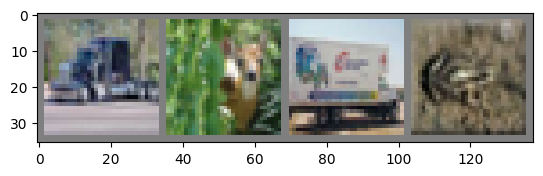

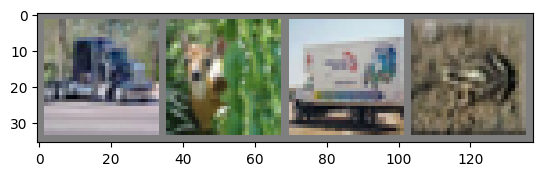

In [ ]:
dataiter = iter(train_loader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images[:4]))

imshow(torchvision.utils.make_grid(transforms.functional.hflip(images[:4])))

Наиболее удобным способом работы с аугментациями в PyTorch является их задание в списке <code>transforms</code>, который затем передается в загрузчик данных. Обучим нашу сеть, применяя горизонтальные повороты:

In [ ]:
transform = transforms.Compose(
        [transforms.RandomHorizontalFlip(),
         transforms.ToTensor(),
         transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
)

train_loader, val_loader, test_loader = get_cifar10_data(batch_size=64, transform_train=transform)

net = BasicBlockNet(3).to(device)
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10, 15], gamma=0.1)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(net, optimizer, 20, train_loader, val_loader, scheduler)

Epoch 0
 train loss: 1.4823294410539938, train acc: 0.47081891492254335
 val loss: 1.293946944399083, val acc: 0.5362367021276596

Epoch 1
 train loss: 1.1841172723055322, train acc: 0.5844011165106319
 val loss: 1.1113181710243225, val acc: 0.6120124114320633

Epoch 2
 train loss: 1.0598152182873686, train acc: 0.630872127233955
 val loss: 1.0752736875351439, val acc: 0.6269281914893617

Epoch 3
 train loss: 0.9982587018440149, train acc: 0.6513082723948812
 val loss: 1.0161484969423171, val acc: 0.6513297872340426

Epoch 4
 train loss: 0.9640654727571407, train acc: 0.6656111256513997
 val loss: 1.005617825021135, val acc: 0.6502437944107867

Epoch 5
 train loss: 0.9324584783104264, train acc: 0.6771513450298274
 val loss: 0.9368936011131773, val acc: 0.6733377659574468

Epoch 6
 train loss: 0.9123417840797243, train acc: 0.6865287934186471
 val loss: 0.9346346938863713, val acc: 0.6720744680851064

Epoch 7
 train loss: 0.8961108140034475, train acc: 0.6895281078610603
 val loss: 0.8

Посчитайте точность на тестовой выборке:

In [ ]:
test(net, test_loader)

(np.float64(0.8036041187632615), np.float64(0.7261146496815286))

**Задание 4.1 (2 балла).** Изучите, какие еще способы аугментаций изображений представлены в <code>torchvision.transforms</code>. Выберите несколько из них, объясните, как они устроены, и обучите модель с ними (по отдельности и вместе). Удалось ли добиться улучшения качества на тестовой выборке?

In [ ]:
criterion = nn.CrossEntropyLoss()

def test(model, loader):
    loss_log = []
    acc_log = []
    model.eval()

    with torch.no_grad():
        for data, target in loader:
            data = data.to(device)
            target = target.to(device)
            logits = model(data)
            loss = criterion(logits, target)
            loss_log.append(loss.item())

            preds = logits.argmax(dim=1)
            acc = (preds == target).float().mean()
            acc_log.append(acc.item())


    return np.mean(loss_log), np.mean(acc_log)

def train_epoch(model, optimizer, train_loader):
    loss_log = []
    acc_log = []
    model.train()

    for data, target in train_loader:
        data = data.to(device)
        target = target.to(device)
        optimizer.zero_grad()
        logits = model(data)
        loss = criterion(logits, target)
        loss.backward()
        optimizer.step()

        loss_log.append(loss.item())

        preds = logits.argmax(dim=1)
        acc = (preds == target).float().mean()

        acc_log.append(acc.item())

    return loss_log, acc_log

def train(model, optimizer, n_epochs, train_loader, val_loader, scheduler=None):
    train_loss_log, train_acc_log, val_loss_log, val_acc_log = [], [], [], []

    for epoch in range(n_epochs):
        train_loss, train_acc = train_epoch(model, optimizer, train_loader)
        val_loss, val_acc = test(model, val_loader)

        train_loss_log.extend(train_loss)
        train_acc_log.extend(train_acc)

        val_loss_log.append(val_loss)
        val_acc_log.append(val_acc)

        print(f"Epoch {epoch}")
        print(f" train loss: {np.mean(train_loss)}, train acc: {np.mean(train_acc)}")
        print(f" val loss: {val_loss}, val acc: {val_acc}\n")

        if scheduler is not None:
            scheduler.step()

    return train_loss_log, train_acc_log, val_loss_log, val_acc_log

## 1) ColorJitter

меняет яркость, контраст и насыщенность

параметры изображения случайно масштабируются:
$$ x' = a \cdot x $$



## 2) RandomErasing

случайно вырезается прямоугольную область и заменяется шумом или константой


## 3) Solarize

инвертируется яркость только тех пикселей, которые выше порога


In [ ]:
#ColorJitter

transform = transforms.Compose(
    [
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ]
)


train_loader, val_loader, test_loader = get_cifar10_data(batch_size=64, transform_train=transform)

net = BasicBlockNet(3).to(device)
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10, 15], gamma=0.1)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(net, optimizer, 20, train_loader, val_loader, scheduler)


с1, d1 = test(net, test_loader)


#RandomErasing
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        transforms.RandomErasing(p=0.5, scale=(0.02, 0.2), ratio=(0.3, 3.3)),
    ]
)


train_loader, val_loader, test_loader = get_cifar10_data(batch_size=64, transform_train=transform)

net = BasicBlockNet(3).to(device)
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10, 15], gamma=0.1)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(net, optimizer, 20, train_loader, val_loader, scheduler)
с2, d2 = test(net, test_loader)


#Solarize
transform = transforms.Compose(
    [
        transforms.RandomSolarize(threshold=0.5, p=0.5),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ]
)


train_loader, val_loader, test_loader = get_cifar10_data(batch_size=64, transform_train=transform)

net = BasicBlockNet(3).to(device)
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10, 15], gamma=0.1)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(net, optimizer, 20, train_loader, val_loader, scheduler)
с3, d3 = test(net, test_loader)



Epoch 0
 train loss: 1.5502245197348445, train acc: 0.4467305433161734
 val loss: 1.3666657173887211, val acc: 0.5123670212765957

Epoch 1
 train loss: 1.2210317450206065, train acc: 0.5749338927391024
 val loss: 1.1238109717977809, val acc: 0.6097074468085106

Epoch 2
 train loss: 1.0918818058435835, train acc: 0.6197032515483974
 val loss: 1.0934422769445054, val acc: 0.6249778369639782

Epoch 3
 train loss: 1.0302991013858174, train acc: 0.6456932293649565
 val loss: 1.0218349139741127, val acc: 0.6500443263256803

Epoch 4
 train loss: 0.9929471307960245, train acc: 0.6555807652595492
 val loss: 1.0317599768334247, val acc: 0.6417109930768926

Epoch 5
 train loss: 0.9649876803976962, train acc: 0.665476462522852
 val loss: 0.9890851573741183, val acc: 0.6524822695458189

Epoch 6
 train loss: 0.9408316343641369, train acc: 0.6756170018281535
 val loss: 0.9681259644792435, val acc: 0.6648492909492331

Epoch 7
 train loss: 0.9279817805865564, train acc: 0.6792488248518224
 val loss: 0.

In [ ]:
print(f'ColorJitter: {d1}')
print(f'RandomErasing:{d2}')
print(f'Solarize: {d3}')


ColorJitter: 0.7131767515923567
RandomErasing:0.7116839171974523
Solarize: 0.6714769108280255


В итоге мы увидели, что все хуже чем FlifHorizontal. Но, справедливости ради, лучше, чем baseline

## Бонус. Логирование в comet (2 балла)

На практике специалиста по глубинному обучению часто встречаются ситуации, когда нейросеть учится на каком-то удаленном сервере. И обычно вам хочется отслеживать прогресс обучения, особенно когда время обучения модели исчисляется днями или неделями. Для таких целей существует несколько инструментов. ~~Вероятно, самый популярный из них — [wandb](https://wandb.ai/site)~~ Например: [TensorBoard](https://docs.pytorch.org/tutorials/recipes/recipes/tensorboard_with_pytorch.html), [comet](https://www.comet.com), [wandb](https://wandb.ai/). Выберите любой удобный из них.

Ваша задача состоит в том, чтобы разобраться как им пользоваться, и повторить задания 2.1 и 2.2 с его использованием. Обучение вы можете запускать в этом же ноутбуке, но теперь вам необходимо логировать значения функции потерь и точности на обучающей выборке и на валидационной. Результатом работы должны быть ваш код, публичная ссылка на страничку с графиками, идентичными графикам в задании 2.2 или выхлоп тензорбоард.

In [ ]:
pip install comet-ml


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.0/780.0 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 52.3 MB/s eta 0:00:00
  Attempting uninstall: python-box
    Found existing installation: python-box 7.3.2
    Uninstalling python-box-7.3.2:
      Successfully uninstalled python-box-7.3.2


In [12]:
from comet_ml import Experiment

experiment = Experiment(
    api_key="99TpBwRh7XD7uotKEoUKQnBJi",
    project_name="cifar10-resnet",
    workspace="ivan-brazil"
)


COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: sklearn, torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/ivan-brazil/cifar10-resnet/3c86eaf95e0149d898bcebc8009fbd3d



In [57]:
import torch, numpy as np, random

torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

net = BasicBlockNet(3).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)


In [58]:
from comet_ml import Experiment

experiment = Experiment(
    api_key="99TpBwRh7XD7uotKEoUKQnBJi",
    project_name="cifar10-resnet",
    workspace="ivan-brazil"
)

criterion = nn.CrossEntropyLoss()
global_step = 0


def test(model, loader):
    global global_step

    loss_log = []
    acc_log = []
    model.eval()

    with torch.no_grad():
        for data, target in loader:
            data = data.to(device)
            target = target.to(device)
            logits = model(data)
            loss = criterion(logits, target)
            loss_log.append(loss.item())

            preds = logits.argmax(dim=1)
            acc = (preds == target).float().mean()
            acc_log.append(acc.item())

    loss_mean = np.mean(loss_log)
    acc_mean = np.mean(acc_log)

    experiment.log_metric("loss_val", loss_mean, step=global_step)
    experiment.log_metric("acc_val", acc_mean, step=global_step)
    experiment.log_metric("loss_val", loss_mean, step=global_step)
    experiment.log_metric("acc_val", acc_mean, step=global_step)

    return loss_mean, acc_mean


def train_epoch(model, optimizer, train_loader):
    global global_step

    loss_log = []
    acc_log = []
    model.train()

    for data, target in train_loader:
        data = data.to(device)
        target = target.to(device)

        optimizer.zero_grad()
        logits = model(data)
        loss = criterion(logits, target)
        loss.backward()
        optimizer.step()

        loss_log.append(loss.item())

        preds = logits.argmax(dim=1)
        acc = (preds == target).float().mean()
        acc_log.append(acc.item())

        experiment.log_metric("loss_train", loss.item(), step=global_step)
        experiment.log_metric("acc_train", acc.item(), step=global_step)

        global_step += 1

    return loss_log, acc_log


def train(model, optimizer, n_epochs, train_loader, val_loader, scheduler=None):
    train_loss_log, train_acc_log, val_loss_log, val_acc_log = [], [], [], []

    for epoch in range(n_epochs):
        train_loss, train_acc = train_epoch(model, optimizer, train_loader)
        val_loss, val_acc = test(model, val_loader)

        train_loss_log.extend(train_loss)
        train_acc_log.extend(train_acc)

        val_loss_log.append(val_loss)
        val_acc_log.append(val_acc)

        print(f"Epoch {epoch}")
        print(f" train loss: {np.mean(train_loss)}, train acc: {np.mean(train_acc)}")
        print(f" val loss: {val_loss}, val acc: {val_acc}\n")

        if scheduler is not None:
            scheduler.step()

    return train_loss_log, train_acc_log, val_loss_log, val_acc_log


optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)

train_loss_log, train_acc_log, val_loss_log, val_acc_log = \
    train(net, optimizer, 20, train_loader, val_loader)

experiment.end()


COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: sklearn, torch.
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : delightful_parrotfish_7572
COMET INFO:     url                   : https://www.comet.com/ivan-brazil/cifar10-resnet/470d989a51784b1c8f04c4e37ced05a1
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     acc_train [7111]  : (0.078125, 0.90625)
COMET INFO:     acc_val [12]      : (0.5341090425531915, 0.6992686170212766)
COMET INFO:     loss_train [7111] : (0.35252779722213745, 2.605924367904663)
COMET INFO:     loss_val [12]     : (0.8786029427609545, 1.2986544492396903)
COMET INFO:   Others:
COMET INFO:     notebook_url : https://cola

Epoch 0
 train loss: 1.4951245987437107, train acc: 0.4688765017598377
 val loss: 1.2695171840647435, val acc: 0.5428413122258288

Epoch 1
 train loss: 1.1875482722435835, train acc: 0.5829810329067642
 val loss: 1.0975588068049005, val acc: 0.6167996454746165

Epoch 2
 train loss: 1.0646415145785106, train acc: 0.6311496148597606
 val loss: 1.0568409856329573, val acc: 0.6339317377577437

Epoch 3
 train loss: 1.0020785914696548, train acc: 0.6530752154765225
 val loss: 0.9950468971374187, val acc: 0.6555407803109352

Epoch 4
 train loss: 0.9614210360882705, train acc: 0.6658110799475605
 val loss: 1.0123463993376873, val acc: 0.6462987590343394

Epoch 5
 train loss: 0.9279729274988611, train acc: 0.6774696396081495
 val loss: 1.0068180964348163, val acc: 0.6511303191489362

Epoch 6
 train loss: 0.9052386533407668, train acc: 0.6861370463040019
 val loss: 0.9764181999450035, val acc: 0.661923758907521

Epoch 7
 train loss: 0.8904925525406379, train acc: 0.6905809284564128
 val loss: 0.

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : original_laminate_660
COMET INFO:     url                   : https://www.comet.com/ivan-brazil/cifar10-resnet/06d5d4dee7f34327ba9ae5f466ae5e48
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     acc_train [10940]  : (0.078125, 0.90625)
COMET INFO:     acc_val [40]       : (0.5428413122258288, 0.7109929079705096)
COMET INFO:     loss_train [10940] : (0.39538994431495667, 2.605924606323242)
COMET INFO:     loss_val [40]      : (0.8632791694174422, 1.2695171840647435)
COMET INFO:   Others:
COMET INFO:     notebook_url : https://colab.research.google.com/notebook#fileId=17AicaC3CWWasvnMhasruhuMWLsHVgZ8k
COMET INFO:   Uploads:
COMET INFO:     envir